In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d maricinnamon/caltech101-butterfly-dalmatian-dolphin

Dataset URL: https://www.kaggle.com/datasets/maricinnamon/caltech101-butterfly-dalmatian-dolphin
License(s): CC-BY-NC-SA-4.0
100% 2.92M/2.92M [00:01<00:00, 1.83MB/s]



In [5]:
!unzip caltech101-butterfly-dalmatian-dolphin.zip -d dataset

Archive:  caltech101-butterfly-dalmatian-dolphin.zip
  inflating: dataset/caltech101_classification/butterfly/image_0001.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0002.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0003.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0004.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0005.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0006.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0007.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0008.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0009.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0010.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0011.jpg  
  inflating: dataset/caltech101_classification/butterfly/image_0012.jpg  
  inflating: dataset/caltech101_classification/butterfly/im

In [6]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)
    break

dataset


In [7]:
!ls dataset

caltech101_classification


In [8]:
!ls dataset -R

dataset:
caltech101_classification

dataset/caltech101_classification:
butterfly  dolphin	      res_dalmatian.txt
dalmatian  res_butterfly.txt  res_dolphin.txt

dataset/caltech101_classification/butterfly:
image_0001.jpg	image_0020.jpg	image_0039.jpg	image_0058.jpg	image_0077.jpg
image_0002.jpg	image_0021.jpg	image_0040.jpg	image_0059.jpg	image_0078.jpg
image_0003.jpg	image_0022.jpg	image_0041.jpg	image_0060.jpg	image_0079.jpg
image_0004.jpg	image_0023.jpg	image_0042.jpg	image_0061.jpg	image_0080.jpg
image_0005.jpg	image_0024.jpg	image_0043.jpg	image_0062.jpg	image_0081.jpg
image_0006.jpg	image_0025.jpg	image_0044.jpg	image_0063.jpg	image_0082.jpg
image_0007.jpg	image_0026.jpg	image_0045.jpg	image_0064.jpg	image_0083.jpg
image_0008.jpg	image_0027.jpg	image_0046.jpg	image_0065.jpg	image_0084.jpg
image_0009.jpg	image_0028.jpg	image_0047.jpg	image_0066.jpg	image_0085.jpg
image_0010.jpg	image_0029.jpg	image_0048.jpg	image_0067.jpg	image_0086.jpg
image_0011.jpg	image_0030.jpg	image_0049.jpg

Loaded images: (195, 224, 224, 3)
Loaded bboxes: (195, 4)
Loaded labels: (195,)
Classes: ['butterfly', 'dalmatian', 'dolphin']

Split sizes:
Train: (136, 224, 224, 3) (136, 3) (136, 4)
Val  : (29, 224, 224, 3) (29, 3) (29, 4)
Test : (30, 224, 224, 3) (30, 3) (30, 4)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_MultiTask"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 3)         │        771 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │      1,028 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - bbox_output_loss: 0.2919 - bbox_output_mae: 0.4034 - class_output_accuracy: 0.3309 - class_output_loss: 5.1040 - loss: 6.7562 - val_bbox_output_loss: 0.2298 - val_bbox_output_mae: 0.3446 - val_class_output_accuracy: 0.6552 - val_class_output_loss: 0.8262 - val_loss: 2.0123 - learning_rate: 1.0000e-04
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - bbox_output_loss: 0.2534 - bbox_output_mae: 0.3619 - class_output_accuracy: 0.5294 - class_output_loss: 2.9402 - loss: 4.0682 - val_bbox_output_loss: 0.1681 - val_bbox_output_mae: 0.2740 - val_class_output_accuracy: 0.9310 - val_class_output_loss: 0.2000 - val_loss: 1.0684 - learning_rate: 1.0000e-04
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - bbox_output_loss: 0.1919 - bbox_output_mae: 0.2946 - class_output_accuracy: 0.6250 - class_output_loss: 1.7988 - loss: 2.8479 - val_bbox_output_loss: 0.1273 - val_bbox_output_mae: 0.2265 - val_class_output_accuracy: 1.0000 - val_class_output_

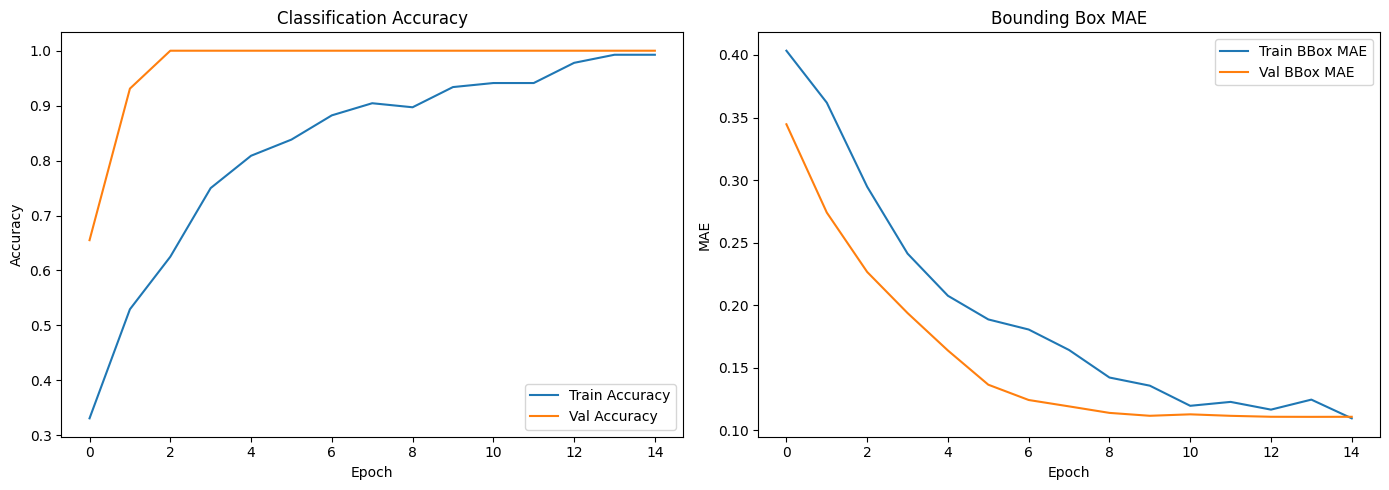


========== SAMPLE PREDICTIONS ==========


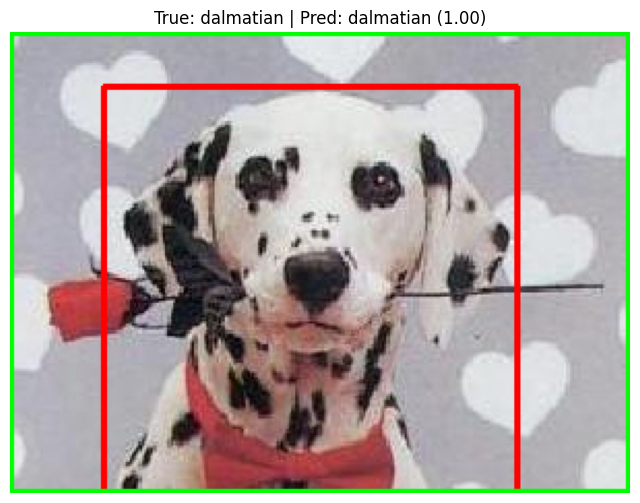

Image path: /content/dataset/caltech101_classification/dalmatian/image_0035.jpg
True class: dalmatian
Predicted class: dalmatian
True bbox: [45, 26, 245, 222]
Predicted bbox: [0, 0, 299, 222]


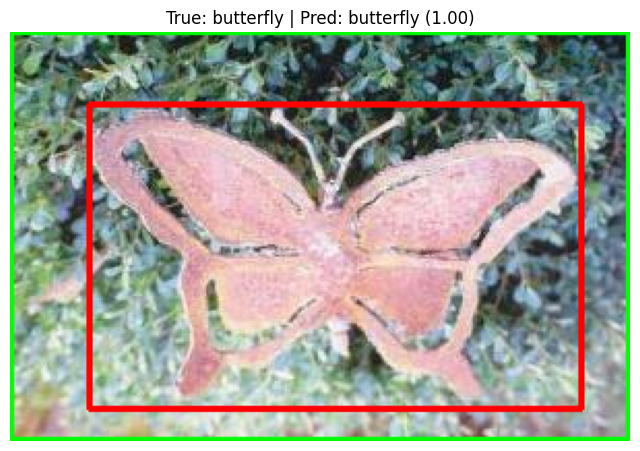

Image path: /content/dataset/caltech101_classification/butterfly/image_0036.jpg
True class: butterfly
Predicted class: butterfly
True bbox: [38, 35, 276, 182]
Predicted bbox: [0, 0, 299, 197]


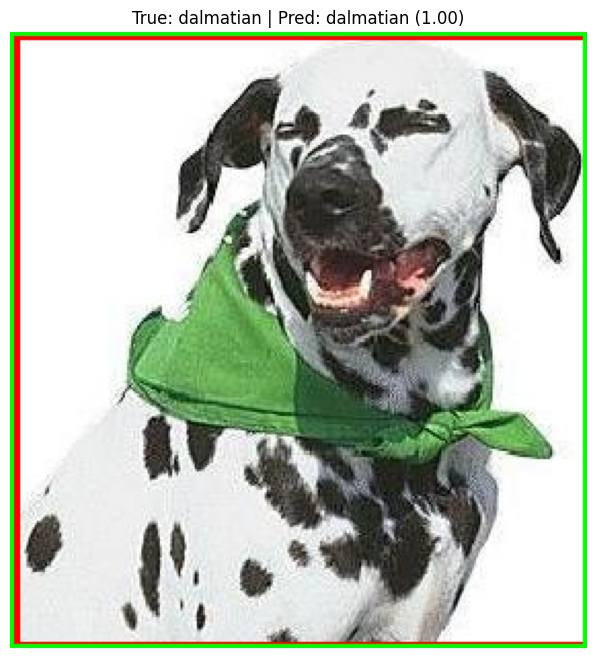

Image path: /content/dataset/caltech101_classification/dalmatian/image_0026.jpg
True class: dalmatian
Predicted class: dalmatian
True bbox: [3, 2, 280, 298]
Predicted bbox: [0, 0, 280, 299]

Saved final model as: vgg16_bbox_classifier_final.keras


In [9]:
# =====================================================
# CV LAB 10 - FINAL COMPLETE COLAB CODE
# Object Classification + Bounding Box Regression
# VGG16 Multi-Output Model
# =====================================================

!pip -q install tensorflow opencv-python scikit-learn matplotlib

import os
import re
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# =====================================================
# 1) REPRODUCIBILITY
# =====================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =====================================================
# 2) CONFIG
# =====================================================

BASE_PATH = "/content/dataset/caltech101_classification"   # change if needed
CLASSES = ["butterfly", "dalmatian", "dolphin"]
IMG_SIZE = 224
BATCH_SIZE = 16

# =====================================================
# 3) HELPERS
# =====================================================

def extract_index(name):
    m = re.search(r"\d+", str(name))
    return int(m.group()) if m else None

def parse_bbox_file(txt_path):
    """
    Expected annotation line format:
    image_0001.jpg, x1, y1, x2, y2
    """
    bbox_dict = {}
    with open(txt_path, "r", encoding="utf-8-sig") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 5:
                continue

            idx = extract_index(parts[0])
            if idx is None:
                continue

            try:
                x1 = int(float(parts[1]))
                y1 = int(float(parts[2]))
                x2 = int(float(parts[3]))
                y2 = int(float(parts[4]))
                bbox_dict[idx] = [x1, y1, x2, y2]
            except:
                continue

    return bbox_dict

def denorm_bbox(bbox_norm, h, w):
    x1 = int(np.clip(bbox_norm[0] * w, 0, w - 1))
    y1 = int(np.clip(bbox_norm[1] * h, 0, h - 1))
    x2 = int(np.clip(bbox_norm[2] * w, 0, w - 1))
    y2 = int(np.clip(bbox_norm[3] * h, 0, h - 1))
    return [x1, y1, x2, y2]

def draw_boxes(img_rgb, true_box=None, pred_box=None):
    out = img_rgb.copy()

    if true_box is not None:
        x1, y1, x2, y2 = true_box
        cv2.rectangle(out, (x1, y1), (x2, y2), (255, 0, 0), 2)  # blue = true

    if pred_box is not None:
        x1, y1, x2, y2 = pred_box
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)  # green = pred

    return out

# =====================================================
# 4) LOAD DATA
# =====================================================

images = []
bbox_targets = []
label_ids = []
image_paths = []

for class_id, cls in enumerate(CLASSES):
    class_folder = os.path.join(BASE_PATH, cls)
    bbox_file = os.path.join(BASE_PATH, f"res_{cls}.txt")

    if not os.path.exists(class_folder):
        raise FileNotFoundError(f"Class folder not found: {class_folder}")
    if not os.path.exists(bbox_file):
        raise FileNotFoundError(f"Annotation file not found: {bbox_file}")

    bbox_dict = parse_bbox_file(bbox_file)

    img_files = sorted([
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    for img_name in img_files:
        idx = extract_index(img_name)
        if idx is None or idx not in bbox_dict:
            continue

        img_path = os.path.join(class_folder, img_name)
        img_bgr = cv2.imread(img_path)

        if img_bgr is None:
            continue

        h, w = img_bgr.shape[:2]
        x1, y1, x2, y2 = bbox_dict[idx]

        bbox_norm = [x1 / w, y1 / h, x2 / w, y2 / h]

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_proc = preprocess_input(img_rgb.astype(np.float32))

        images.append(img_proc)
        bbox_targets.append(bbox_norm)
        label_ids.append(class_id)
        image_paths.append(img_path)

images = np.array(images, dtype=np.float32)
bbox_targets = np.array(bbox_targets, dtype=np.float32)
label_ids = np.array(label_ids, dtype=np.int32)
image_paths = np.array(image_paths)

print("Loaded images:", images.shape)
print("Loaded bboxes:", bbox_targets.shape)
print("Loaded labels:", label_ids.shape)
print("Classes:", CLASSES)

# =====================================================
# 5) TRAIN / VAL / TEST SPLIT
# =====================================================

X_train, X_temp, y_train_id, y_temp_id, ybox_train, ybox_temp, path_train, path_temp = train_test_split(
    images,
    label_ids,
    bbox_targets,
    image_paths,
    test_size=0.30,
    random_state=SEED,
    stratify=label_ids
)

X_val, X_test, y_val_id, y_test_id, ybox_val, ybox_test, path_val, path_test = train_test_split(
    X_temp,
    y_temp_id,
    ybox_temp,
    path_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_id
)

y_train_cls = tf.keras.utils.to_categorical(y_train_id, num_classes=len(CLASSES))
y_val_cls   = tf.keras.utils.to_categorical(y_val_id, num_classes=len(CLASSES))
y_test_cls  = tf.keras.utils.to_categorical(y_test_id, num_classes=len(CLASSES))

print("\nSplit sizes:")
print("Train:", X_train.shape, y_train_cls.shape, ybox_train.shape)
print("Val  :", X_val.shape, y_val_cls.shape, ybox_val.shape)
print("Test :", X_test.shape, y_test_cls.shape, ybox_test.shape)

# =====================================================
# 6) tf.data PIPELINE
# =====================================================

def make_dataset(X, y_cls, y_box, training=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (X, {"class_output": y_cls, "bbox_output": y_box})
    )
    if training:
        ds = ds.shuffle(512, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train_cls, ybox_train, training=True)
val_ds   = make_dataset(X_val, y_val_cls, ybox_val, training=False)
test_ds  = make_dataset(X_test, y_test_cls, ybox_test, training=False)

# =====================================================
# 7) BUILD MODEL
# =====================================================

base = VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

class_output = layers.Dense(len(CLASSES), activation="softmax", name="class_output")(x)
bbox_output  = layers.Dense(4, activation="sigmoid", name="bbox_output")(x)

model = models.Model(inputs=inputs, outputs=[class_output, bbox_output], name="VGG16_MultiTask")
model.summary()

# =====================================================
# 8) COMPILE
# =====================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "class_output": "categorical_crossentropy",
        "bbox_output": "mse"
    },
    loss_weights={
        "class_output": 1.0,
        "bbox_output": 5.0
    },
    metrics={
        "class_output": ["accuracy"],
        "bbox_output": ["mae"]
    }
)

# =====================================================
# 9) CALLBACKS
# =====================================================

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_vgg16_bbox_classifier.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

# =====================================================
# 10) TRAIN PHASE 1
# =====================================================

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

# =====================================================
# 11) FINE-TUNING PHASE 2
# =====================================================

base.trainable = True
for layer in base.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "class_output": "categorical_crossentropy",
        "bbox_output": "mse"
    },
    loss_weights={
        "class_output": 1.0,
        "bbox_output": 5.0
    },
    metrics={
        "class_output": ["accuracy"],
        "bbox_output": ["mae"]
    }
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

# =====================================================
# 12) EVALUATION
# =====================================================

eval_results = model.evaluate(test_ds, verbose=1)
print("\nModel metrics:")
for name, value in zip(model.metrics_names, eval_results):
    print(f"{name}: {value:.4f}")

# =====================================================
# 13) TRAIN / VAL / TEST METRICS
# =====================================================

train_class_probs, train_box_preds = model.predict(X_train, verbose=0)
val_class_probs, val_box_preds     = model.predict(X_val, verbose=0)
test_class_probs, test_box_preds   = model.predict(X_test, verbose=0)

train_class_acc = np.mean(np.argmax(train_class_probs, axis=1) == y_train_id)
val_class_acc   = np.mean(np.argmax(val_class_probs, axis=1) == y_val_id)
test_class_acc  = np.mean(np.argmax(test_class_probs, axis=1) == y_test_id)

train_bbox_mae = np.mean(np.abs(train_box_preds - ybox_train))
val_bbox_mae   = np.mean(np.abs(val_box_preds - ybox_val))
test_bbox_mae  = np.mean(np.abs(test_box_preds - ybox_test))

print("\n========== FINAL METRICS ==========")
print(f"Training Classification Accuracy: {train_class_acc * 100:.2f}%")
print(f"Validation Classification Accuracy: {val_class_acc * 100:.2f}%")
print(f"Test Classification Accuracy: {test_class_acc * 100:.2f}%")
print(f"Training Bounding Box MAE: {train_bbox_mae:.4f}")
print(f"Validation Bounding Box MAE: {val_bbox_mae:.4f}")
print(f"Test Bounding Box MAE: {test_bbox_mae:.4f}")

# =====================================================
# 14) COMBINE HISTORY FOR PLOTS
# =====================================================

combined_history = {}
all_keys = set(history1.history.keys()) | set(history2.history.keys())
for k in all_keys:
    combined_history[k] = history1.history.get(k, []) + history2.history.get(k, [])

# =====================================================
# 15) PLOTS
# =====================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
if "class_output_accuracy" in combined_history:
    plt.plot(combined_history["class_output_accuracy"], label="Train Accuracy")
if "val_class_output_accuracy" in combined_history:
    plt.plot(combined_history["val_class_output_accuracy"], label="Val Accuracy")
plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
if "bbox_output_mae" in combined_history:
    plt.plot(combined_history["bbox_output_mae"], label="Train BBox MAE")
if "val_bbox_output_mae" in combined_history:
    plt.plot(combined_history["val_bbox_output_mae"], label="Val BBox MAE")
plt.title("Bounding Box MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

# =====================================================
# 16) VISUALIZE SAMPLE PREDICTIONS
# =====================================================

def visualize_prediction(index=0):
    img_path = path_test[index]
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print("Could not read:", img_path)
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    inp = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    inp = preprocess_input(inp)
    inp = np.expand_dims(inp, axis=0)

    class_probs, bbox_pred = model.predict(inp, verbose=0)
    pred_class_id = int(np.argmax(class_probs[0]))
    pred_conf = float(np.max(class_probs[0]))
    pred_bbox = denorm_bbox(bbox_pred[0], h, w)

    true_bbox = denorm_bbox(ybox_test[index], h, w)
    true_class_id = int(y_test_id[index])

    vis = draw_boxes(img_rgb, true_box=true_bbox, pred_box=pred_bbox)

    plt.figure(figsize=(8, 8))
    plt.imshow(vis)
    plt.axis("off")
    plt.title(f"True: {CLASSES[true_class_id]} | Pred: {CLASSES[pred_class_id]} ({pred_conf:.2f})")
    plt.show()

    print("Image path:", img_path)
    print("True class:", CLASSES[true_class_id])
    print("Predicted class:", CLASSES[pred_class_id])
    print("True bbox:", true_bbox)
    print("Predicted bbox:", pred_bbox)

print("\n========== SAMPLE PREDICTIONS ==========")
for i in range(min(3, len(X_test))):
    visualize_prediction(i)

# =====================================================
# 17) SAVE FINAL MODEL
# =====================================================

model.save("vgg16_bbox_classifier_final.keras")
print("\nSaved final model as: vgg16_bbox_classifier_final.keras")